# Session 21 — Word Embeddings: Words as Vectors that Capture Meaning

**Goal of this notebook:** move from *counting* words (Session 20) to *understanding* them.

In Session 20 we built One-Hot, Bag-of-Words and TF-IDF. They all share one blind spot: **they never learn that words can be related**. `cat` is no closer to `dog` than to `helicopter`.

Word **embeddings** fix this by representing every word as a short list of learned numbers — a **vector** — so that words used in similar contexts end up close together. Meaning becomes *geometry*.

We will, step by step:

1. Measure similarity between vectors with **cosine similarity** (by hand, then with a library).
2. Train **Word2Vec** ourselves — both **CBOW** and **Skip-Gram**.
3. Do **vector arithmetic** (the famous *king − man + woman ≈ queen*).
4. Load **pre-trained GloVe** vectors and see real-world similarity & analogies.
5. Train **FastText** and watch it handle **unknown / misspelled words** via subwords.
6. **Visualise** an embedding space in 2-D.

> Everything here is runnable. The only step that needs the internet is the pre-trained GloVe download — it is wrapped so the notebook keeps working offline.

## 0. Setup

We use `gensim` (the standard library for Word2Vec / FastText / GloVe), plus `numpy`, `scikit-learn` and `matplotlib`.
Run the install line once if these are not already present.

In [1]:
# Run once if needed (uncomment):
# !pip install gensim numpy scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt

import gensim
from gensim.models import Word2Vec, FastText

np.random.seed(42)
print("gensim version:", gensim.__version__)
print("Ready.")

gensim version: 4.4.0
Ready.


---
## 1. Cosine Similarity — measuring closeness

Two words are similar if their vectors **point in the same direction**. Cosine similarity measures the angle between two vectors, ignoring their length:

$$\cos(\theta) = \frac{A \cdot B}{\lVert A \rVert \, \lVert B \rVert}$$

- **+1** → same direction → very similar
- **0** → perpendicular → unrelated
- **−1** → opposite → very different

Let's implement it from scratch with three tiny hand-made vectors so the mechanic is obvious.

In [2]:
def cosine_similarity(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Three toy 2-D "word vectors"
cat    = np.array([2.0, 3.0])   # a pet
dog    = np.array([3.0, 4.0])   # also a pet  -> should be close to cat
car    = np.array([5.0, -1.0])  # a vehicle   -> should be far from both

print(f"cosine(cat, dog) = {cosine_similarity(cat, dog):.3f}   <- high: similar")
print(f"cosine(cat, car) = {cosine_similarity(cat, car):.3f}   <- low : different")

cosine(cat, dog) = 0.998   <- high: similar
cosine(cat, car) = 0.381   <- low : different


**Why cosine and not plain distance?** Cosine looks only at *direction*. A document that simply repeats a word many times has a *longer* vector but the same *meaning* — cosine ignores that length and compares orientation. That is exactly what we want for comparing meaning.

`scikit-learn` gives the same result for many vectors at once:

In [3]:
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

V = np.vstack([cat, dog, car])
labels = ["cat", "dog", "car"]
sim = sk_cosine(V)

import pandas as pd
pd.DataFrame(sim, index=labels, columns=labels).round(3)

,cat,dog,car
cat,1.000,0.998,0.381
dog,0.998,1.000,0.431
car,0.381,0.431,1.000


---
## 2. Training Word2Vec: CBOW vs Skip-Gram

**Word2Vec** (Mikolov et al., Google, 2013) trains a shallow neural network on a simple prediction game over a sliding window of text. We don't care about the predictions themselves — **the hidden-layer weights become the word vectors.**

Two flavours:

| Model | Predicts | `sg` flag in gensim |
|-------|----------|---------------------|
| **CBOW** | centre word **from** its context | `sg=0` |
| **Skip-Gram** | context **from** the centre word | `sg=1` |

Real embeddings need huge corpora. To keep this runnable and readable we use a small **themed toy corpus** — sentences about royalty, gender, pets and countries — with repeated patterns so the model can learn stable neighbours inside this little world.

In [4]:
# A small, themed corpus. Each inner list is one tokenised sentence.
sentences = [
    ["the", "king", "is", "a", "strong", "man"],
    ["the", "queen", "is", "a", "wise", "woman"],
    ["the", "king", "rules", "the", "kingdom"],
    ["the", "queen", "rules", "the", "kingdom"],
    ["the", "prince", "is", "a", "young", "man"],
    ["the", "princess", "is", "a", "young", "woman"],
    ["the", "king", "loves", "the", "queen"],
    ["the", "man", "is", "the", "king", "of", "the", "kingdom"],
    ["the", "woman", "is", "the", "queen", "of", "the", "kingdom"],
    ["a", "man", "and", "a", "woman"],
    ["the", "cat", "is", "a", "small", "pet"],
    ["the", "dog", "is", "a", "loyal", "pet"],
    ["the", "cat", "and", "the", "dog", "are", "pets"],
    ["the", "dog", "chased", "the", "cat"],
    ["the", "kitten", "is", "a", "young", "cat"],
    ["the", "puppy", "is", "a", "young", "dog"],
    ["paris", "is", "the", "capital", "of", "france"],
    ["berlin", "is", "the", "capital", "of", "germany"],
    ["rome", "is", "the", "capital", "of", "italy"],
    ["madrid", "is", "the", "capital", "of", "spain"],
    ["france", "and", "germany", "are", "countries"],
    ["italy", "and", "spain", "are", "countries"],
]
# Repeat the corpus a few times so the tiny model sees enough examples.
corpus = sentences * 40
print("sentences:", len(corpus), " | unique words:", len(set(w for s in sentences for w in s)))

sentences: 880  | unique words: 37


In [5]:
# Train both variants on the SAME data, changing only sg=0 (CBOW) vs sg=1 (Skip-Gram).
common = dict(vector_size=50, window=2, min_count=1, workers=1, epochs=120, seed=42)

cbow      = Word2Vec(corpus, sg=0, **common)   # CBOW
skipgram  = Word2Vec(corpus, sg=1, **common)   # Skip-Gram

print("Vocabulary size:", len(cbow.wv))
print("Vector for 'king' (first 8 of 50 numbers):")
print(np.round(cbow.wv['king'][:8], 3))

Vocabulary size: 37
Vector for 'king' (first 8 of 50 numbers):
[0.179 0.824 0.509 0.295 0.504 0.022 0.201 0.715]


### Nearest neighbours

`most_similar` ranks every other word by cosine similarity. Inside our toy world, royal words should cluster, and pets should cluster.

In [6]:
for word in ["king", "cat", "france"]:
    print(f"Most similar to '{word}' (Skip-Gram):")
    for other, score in skipgram.wv.most_similar(word, topn=3):
        print(f"    {other:<10} {score:.3f}")
    print()

Most similar to 'king' (Skip-Gram):
    queen      0.735
    kingdom    0.647
    rules      0.600

Most similar to 'cat' (Skip-Gram):
    dog        0.660
    puppy      0.641
    loyal      0.601

Most similar to 'france' (Skip-Gram):
    berlin     0.732
    germany    0.693
    spain      0.632



In [7]:
# Direct pairwise similarity
print("similarity(king, queen) :", round(skipgram.wv.similarity('king', 'queen'), 3))
print("similarity(king, cat)   :", round(skipgram.wv.similarity('king', 'cat'),   3))
print("similarity(cat, dog)    :", round(skipgram.wv.similarity('cat', 'dog'),    3))

similarity(king, queen) : 0.735
similarity(king, cat)   : 0.198
similarity(cat, dog)    : 0.66


> **Note on toy data:** with such a tiny corpus the exact numbers are noisy and will shift between runs. The point is the *mechanic* — same code, `sg=0` vs `sg=1`. Real quality comes from large corpora, which we use next via pre-trained vectors.

---
## 3. Word Analogies — arithmetic on meaning

Because relationships become consistent *directions* in the space, we can do algebra on words:

$$\text{vec(king)} - \text{vec(man)} + \text{vec(woman)} \approx \text{vec(queen)}$$

In gensim this is `most_similar(positive=[...], negative=[...])`. Let's try it on our toy model (it *hints* at the structure), then do it properly with real vectors in the next section.

In [8]:
def analogy(model, a, b, c, topn=3):
    # a is to b as c is to ?   ==>   b - a + c
    return model.wv.most_similar(positive=[b, c], negative=[a], topn=topn)

print("man : king  ::  woman : ?   (toy model)")
for w, s in analogy(skipgram, "man", "king", "woman"):
    print(f"    {w:<10} {s:.3f}")

man : king  ::  woman : ?   (toy model)
    queen      0.454
    kingdom    0.431
    rules      0.430


---
## 4. Pre-trained GloVe — meaning learned from billions of words

**GloVe** (Pennington, Socher & Manning, Stanford, 2014) learns vectors from **global word co-occurrence counts** across a huge corpus. Pre-trained GloVe vectors are available off-the-shelf through gensim's downloader.

We load `glove-wiki-gigaword-50` (50-dimensional vectors trained on Wikipedia + Gigaword, ~66 MB).

> This is the **only** cell that needs the internet. It is wrapped in `try/except`, so if you are offline the notebook keeps running — you just skip this demo.

In [9]:
glove = None
try:
    import gensim.downloader as api
    glove = api.load("glove-wiki-gigaword-50")   # downloads on first run, then cached
    print("Loaded GloVe:", len(glove), "words, dim =", glove.vector_size)
except Exception as e:
    print("Could not load pre-trained GloVe (offline?). Skipping this section.")
    print("Reason:", repr(e))

Loaded GloVe: 400000 words, dim = 50


In [10]:
if glove is not None:
    print("Most similar to 'king':")
    for w, s in glove.most_similar("king", topn=5):
        print(f"    {w:<12} {s:.3f}")

    print("\nsimilarity(cat, dog)      :", round(glove.similarity("cat", "dog"), 3))
    print("similarity(cat, banana)   :", round(glove.similarity("cat", "banana"), 3))

Most similar to 'king':
    prince       0.824
    queen        0.784
    ii           0.775
    emperor      0.774
    son          0.767

similarity(cat, dog)      : 0.922
similarity(cat, banana)   : 0.34


In [11]:
if glove is not None:
    print("king - man + woman  ≈ ?")
    for w, s in glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3):
        print(f"    {w:<10} {s:.3f}")

    print("\nparis - france + italy  ≈ ?")
    for w, s in glove.most_similar(positive=["paris", "italy"], negative=["france"], topn=3):
        print(f"    {w:<10} {s:.3f}")

    print("\nodd-one-out among [breakfast, cereal, dinner, lunch]:")
    print("   ", glove.doesnt_match(["breakfast", "cereal", "dinner", "lunch"]))

king - man + woman  ≈ ?
    queen      0.852
    throne     0.766
    prince     0.759

paris - france + italy  ≈ ?
    rome       0.847
    milan      0.777
    turin      0.767

odd-one-out among [breakfast, cereal, dinner, lunch]:
    cereal


---
## 5. FastText — words made of pieces

Word2Vec and GloVe treat each word as **atomic**: a word they never saw during training has **no vector at all** (the *out-of-vocabulary* problem).

**FastText** (Bojanowski et al., Facebook AI, 2017) represents a word as the **sum of its character n-grams** (subwords). So even a brand-new or misspelled word still gets a vector, built from its pieces.

We train FastText on the same toy corpus, then ask it for a word that is **not in the vocabulary**.

In [12]:
ft = FastText(corpus, vector_size=50, window=2, min_count=1,
              workers=1, epochs=120, seed=42, min_n=2, max_n=4)

# A word that NEVER appears in our corpus:
unknown = "kingdoms"          # plural form not in vocab
print("'kingdoms' in vocabulary? ->", "kingdoms" in ft.wv.key_to_index)

# Word2Vec would raise KeyError here. FastText builds a vector from subwords:
vec = ft.wv["kingdoms"]
print("FastText still returns a vector, shape:", vec.shape)
print("Nearest known words to the unseen 'kingdoms':")
for w, s in ft.wv.most_similar("kingdoms", topn=3):
    print(f"    {w:<10} {s:.3f}")

'kingdoms' in vocabulary? -> False
FastText still returns a vector, shape: (50,)
Nearest known words to the unseen 'kingdoms':
    kingdom    0.993
    king       0.941
    queen      0.779


In [13]:
# Contrast: a classic Word2Vec model cannot do this at all.
try:
    skipgram.wv["kingdoms"]
except KeyError as e:
    print("Word2Vec on the same unseen word -> KeyError:", e)

Word2Vec on the same unseen word -> KeyError: "Key 'kingdoms' not present"


**Takeaway:** FastText's subwords give it two superpowers — it handles **unknown / misspelled words**, and it captures **morphology** (`play`, `playing`, `played` share subwords, so they get related vectors). This makes it especially strong for rare words and morphologically rich languages.

---
## 6. Visualising the embedding space

Vectors live in 50 dimensions, which we can't see. We use **PCA** to project them down to 2-D so we can plot them. Related words should land near each other.

(This plot is generated from the *actual vectors we just learned* — it is a data visualisation, not a decorative image.)

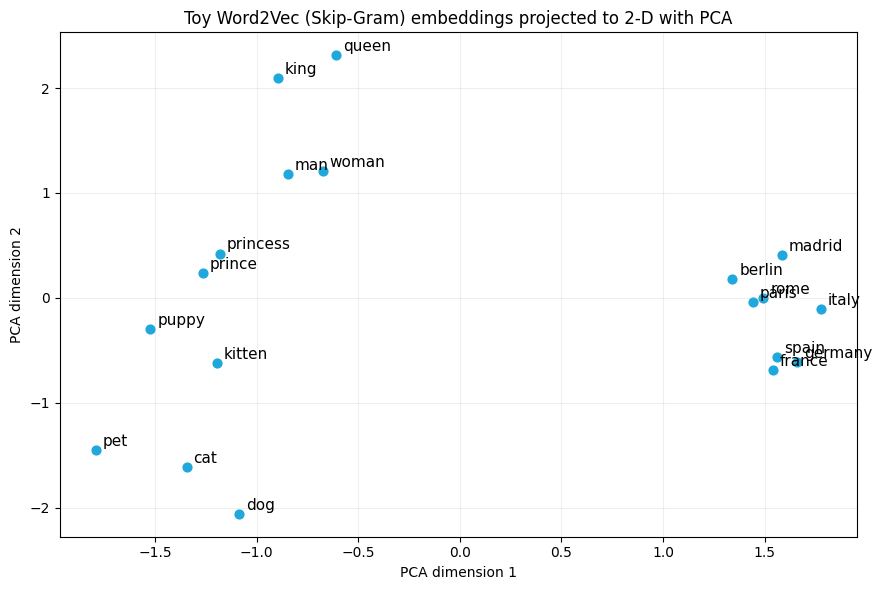

In [14]:
from sklearn.decomposition import PCA

words = ["king", "queen", "prince", "princess", "man", "woman",
         "cat", "dog", "kitten", "puppy", "pet",
         "france", "germany", "italy", "spain", "paris", "berlin", "rome", "madrid"]

vecs = np.vstack([skipgram.wv[w] for w in words])
xy = PCA(n_components=2, random_state=42).fit_transform(vecs)

plt.figure(figsize=(9, 6))
plt.scatter(xy[:, 0], xy[:, 1], s=40, color="#1FA8DC")
for i, w in enumerate(words):
    plt.annotate(w, (xy[i, 0], xy[i, 1]), fontsize=11,
                 xytext=(5, 3), textcoords="offset points")
plt.title("Toy Word2Vec (Skip-Gram) embeddings projected to 2-D with PCA")
plt.xlabel("PCA dimension 1"); plt.ylabel("PCA dimension 2")
plt.grid(alpha=0.2); plt.tight_layout()
plt.show()

---
## Recap

| Idea | What to remember |
|------|------------------|
| **Words → vectors** | Dense numbers learned from context replace sparse counts. |
| **Cosine similarity** | Compare vector *direction* to measure meaning closeness. |
| **Word2Vec** | CBOW (context → word) vs Skip-Gram (word → context); set with `sg`. |
| **Analogies** | Relationships are directions: `king − man + woman ≈ queen`. |
| **GloVe** | Learns from global co-occurrence counts; great pre-trained vectors. |
| **FastText** | Subword n-grams → handles unknown words & morphology. |
| **Limitation** | All are *static*: one vector per word, so `bank` (river vs money) collapses into one point. Contextual models (BERT, transformers) fix this — coming next. |

### References

- Mikolov et al. (2013), *Efficient Estimation of Word Representations in Vector Space* — Word2Vec. arXiv:1301.3781
- Mikolov et al. (2013), *Distributed Representations of Words and Phrases and their Compositionality* — negative sampling. arXiv:1310.4546
- Pennington, Socher & Manning (2014), *GloVe: Global Vectors for Word Representation*, Stanford. https://nlp.stanford.edu/projects/glove/
- Bojanowski, Grave, Joulin & Mikolov (2017), *Enriching Word Vectors with Subword Information* — FastText. arXiv:1607.04606
- gensim documentation: https://radimrehurek.com/gensim/
- Jay Alammar, *The Illustrated Word2vec*: https://jalammar.github.io/illustrated-word2vec/